In [4]:
# Cell 1 — Load & split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/clean_churn.csv")
df = df.dropna()
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5625, 23), Test: (1407, 23)


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.836


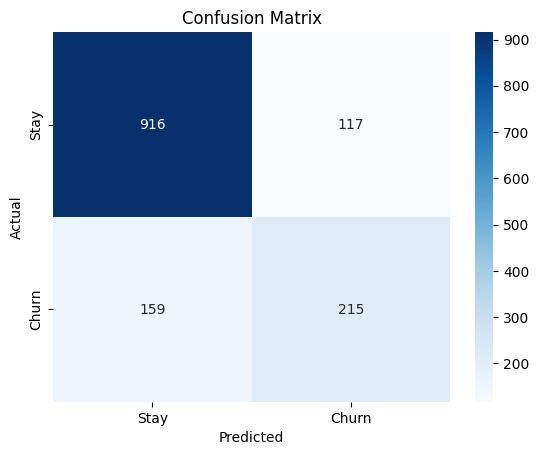

In [5]:
# Cell 2 — Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay","Churn"],
            yticklabels=["Stay","Churn"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

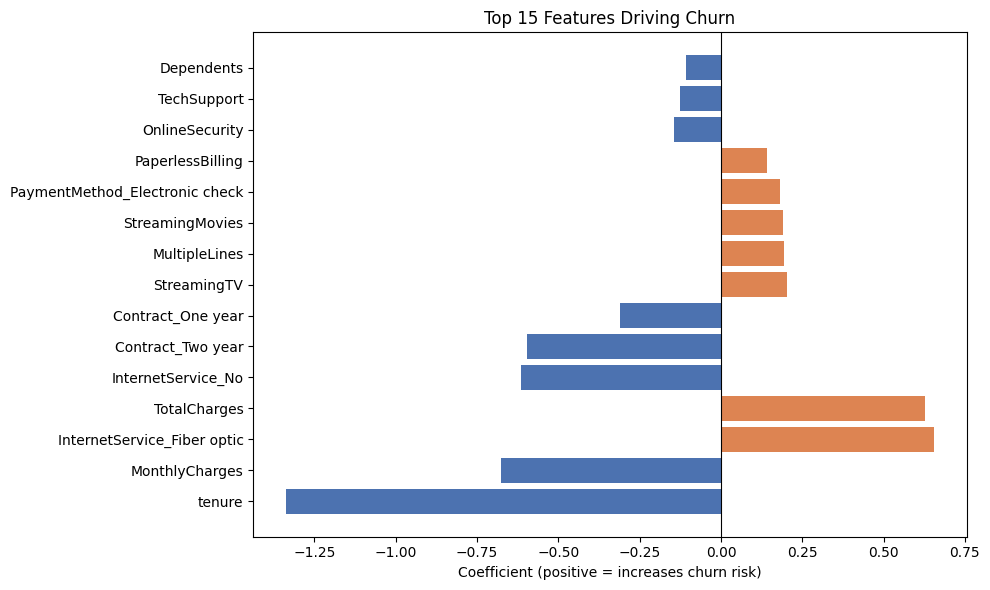

In [6]:
# Cell 3 — Feature importance
import numpy as np

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in feat_imp["coefficient"]]
plt.barh(feat_imp["feature"], feat_imp["coefficient"], color=colors)
plt.title("Top 15 Features Driving Churn")
plt.xlabel("Coefficient (positive = increases churn risk)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [7]:
# Cell 4 — Save model
import joblib, os

os.makedirs("../models", exist_ok=True)
joblib.dump(model,  "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")
print("✅ Model saved")

✅ Model saved
